# 03 - Baseline Forecast

## Objective

This notebook creates two simple one-day-ahead baselines for all products: Last Value and 7-Day Moving Average. A machine learning model should improve on these reference results.

The split uses complete dates: the oldest 80% are training dates and the newest 20% are test dates. No date appears partly in both sets.

**Input:** `data/processed/daily_product_sales.csv`  
**Output:** `reports/baseline_results.csv`  
**Next notebook:** `04_feature_engineering.ipynb`

## Imports and Load Dataset

In [1]:
import os
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

import sys
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(ROOT))
from src.evaluation import evaluate_forecast

DATA_PATH = ROOT / "data" / "processed" / "daily_product_sales.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["sale_date"])
df = df.sort_values(["product_name", "sale_date"]).reset_index(drop=True)
print("Shape:", df.shape)
print("Date range:", df["sale_date"].min(), "to", df["sale_date"].max())

Shape: (6168, 11)
Date range: 2025-01-01 00:00:00 to 2026-05-29 00:00:00


## Temporal Train/Test Split

The first 14 dates are excluded from evaluation so this split matches the date range available after feature engineering. The rows remain available as history for the baseline calculations.

In [2]:
all_dates = df["sale_date"].sort_values().unique()
eligible_dates = all_dates[14:]
split_index = int(len(eligible_dates) * 0.8)
train_dates = eligible_dates[:split_index]
test_dates = eligible_dates[split_index:]

assert train_dates.max() < test_dates.min()
assert set(train_dates).isdisjoint(set(test_dates))

print("Train period:", train_dates.min(), "to", train_dates.max())
print("Test period:", test_dates.min(), "to", test_dates.max())
print("Test dates:", len(test_dates))

Train period: 2025-01-15 00:00:00 to 2026-02-18 00:00:00
Test period: 2026-02-19 00:00:00 to 2026-05-29 00:00:00
Test dates: 100


## Create Baseline Forecasts

In [3]:
baseline_df = df.copy()
grouped_demand = baseline_df.groupby("product_name")["quantity_sold"]

# Both forecasts use only demand before the prediction date.
baseline_df["last_value_forecast"] = grouped_demand.shift(1)
baseline_df["moving_average_7d_forecast"] = grouped_demand.transform(
    lambda values: values.shift(1).rolling(7, min_periods=1).mean()
)

test_baseline = baseline_df[baseline_df["sale_date"].isin(test_dates)].copy()
assert test_baseline[["last_value_forecast", "moving_average_7d_forecast"]].notna().all().all()
test_baseline.head()

,product_name,sale_date,quantity_sold,total_revenue_brl,estimated_profit_brl,discount_pct,unit_price_brl,current_stock_snapshot,supplier_lead_time_days,product_category,weather_condition,last_value_forecast,moving_average_7d_forecast
414,Bag Delivery 45L,2026-02-19,3,528.86,243.86,3.333333,176.286667,28.0,4.0,Bag Entrega,Ensolarado,1.0,2.428571
415,Bag Delivery 45L,2026-02-20,3,543.08,258.08,2.500000,181.405000,37.0,9.0,Bag Entrega,Ensolarado,3.0,2.428571
416,Bag Delivery 45L,2026-02-21,3,546.04,261.04,3.333333,182.013333,102.0,3.0,Bag Entrega,Ensolarado,3.0,2.714286
417,Bag Delivery 45L,2026-02-22,16,2837.58,1317.58,1.111111,177.617778,101.0,9.0,Bag Entrega,Ensolarado,3.0,2.000000
418,Bag Delivery 45L,2026-02-23,4,716.65,336.65,1.666667,179.016667,74.0,6.0,Bag Entrega,Ensolarado,16.0,4.142857


## Evaluate Baselines

MAPE ignores rows where actual demand is zero because division by zero is undefined. It can still be very high for low-demand products, so MAE and RMSE are easier to interpret here.

In [4]:
baseline_results = []
for model_name, prediction_column in {
    "Last Value": "last_value_forecast",
    "7-Day Moving Average": "moving_average_7d_forecast",
}.items():
    metrics = evaluate_forecast(test_baseline["quantity_sold"], test_baseline[prediction_column])
    baseline_results.append({"Model": model_name, **metrics})

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df.round(2)

,Model,MAE,RMSE,MAPE,WAPE
0,Last Value,1.66,2.48,94.93,102.99
1,7-Day Moving Average,1.35,1.93,66.29,83.55


## Visual Comparison

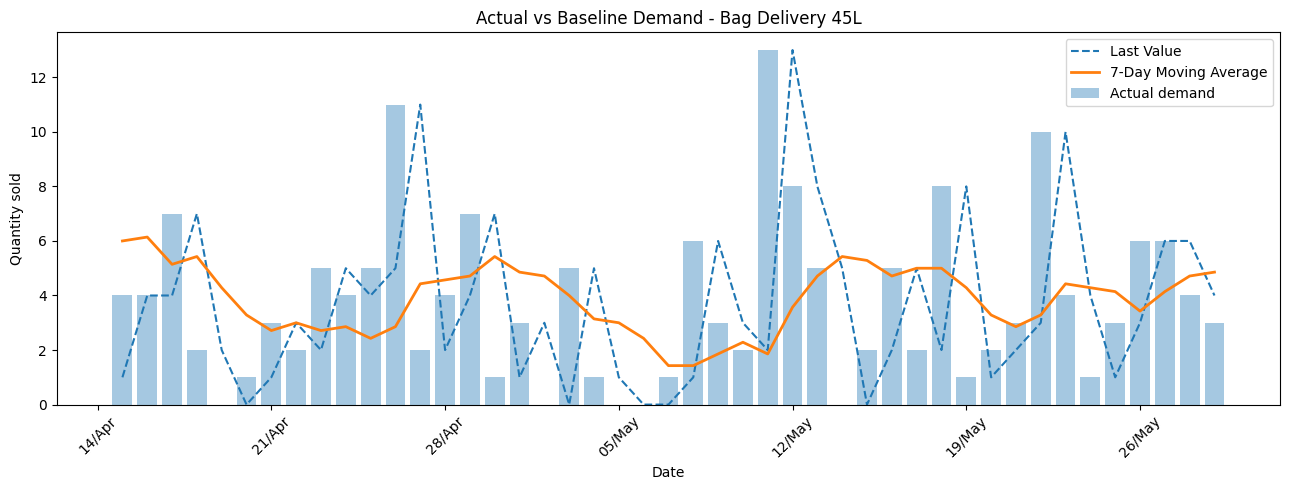

In [5]:
product_name = "Bag Delivery 45L"
plot_df = (
    test_baseline[test_baseline["product_name"] == product_name]
    .sort_values("sale_date")
    .tail(45)
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(plot_df["sale_date"], plot_df["quantity_sold"], alpha=0.4, label="Actual demand")
ax.plot(plot_df["sale_date"], plot_df["last_value_forecast"], "--", label="Last Value")
ax.plot(plot_df["sale_date"], plot_df["moving_average_7d_forecast"], linewidth=2, label="7-Day Moving Average")
ax.set_title(f"Actual vs Baseline Demand - {product_name}")
ax.set_xlabel("Date")
ax.set_ylabel("Quantity sold")
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## Save Results

In [6]:
OUTPUT_PATH = ROOT / "reports" / "baseline_results.csv"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
baseline_results_df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")

best_baseline = baseline_results_df.sort_values("MAE").iloc[0]
print("Best baseline by MAE:", best_baseline["Model"])
print("MAE:", round(best_baseline["MAE"], 2))
print("Saved:", OUTPUT_PATH.resolve())

Best baseline by MAE: 7-Day Moving Average
MAE: 1.35
Saved: C:\DEV\motostock-ai\reports\baseline_results.csv


## Findings, Limitations and Next Step

The 7-Day Moving Average has the lower MAE, so it is the stronger baseline for later model comparison. Last Value reacts quickly but is sensitive to daily changes. The moving average is more stable because it uses seven past days, although it can smooth demand spikes.

These are one-day-ahead evaluations because each test row can use the actual previous day. They do not directly simulate a recursive 14-day forecast. The next notebook creates calendar, lag and rolling features for machine learning models.